# Network IDS Dataset — Exploratory Data Analysis
Dynamic notebook: adapts to whatever CSV files and labels are present.

## 0. Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import math
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')


## 1. Load All CSV Files

In [18]:
DATA_DIR = r'D:/Academic/ML/ModelTraining/dataset/IDS2018/02-15-2018'   # <-- change to your folder

csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024 * 1024)
    print(f'  {f}  ({size_mb:.1f} MB)')


Found 1 CSV files:
  02-15-2018.csv  (358.5 MB)


In [31]:
dfs = []
for f in csv_files:
    path = os.path.join(DATA_DIR, f)
    df_temp = pd.read_csv(path, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    df_temp['source_file'] = f
    print(f'{f}: {df_temp.shape[0]:,} rows, {df_temp.shape[1]} cols')
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape: {df.shape}')


02-15-2018.csv: 1,048,575 rows, 81 cols

Combined shape: (1048575, 81)


## 2. Auto-detect Label Column

In [32]:
# Find the label column: prefer exact 'Label', else first object column
# that looks like a label (low cardinality relative to row count)
def detect_label_column(df, candidates=('Label', 'label', 'Class', 'class', 'Category')):
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: object column with lowest cardinality (but > 1 unique value)
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    obj_cols = [c for c in obj_cols if c != 'source_file']
    if not obj_cols:
        raise ValueError('No candidate label column found. Set LABEL_COL manually.')
    cardinalities = {c: df[c].nunique() for c in obj_cols}
    best = min(cardinalities, key=cardinalities.get)
    print(f'No standard label column found. Using "{best}" (cardinality={cardinalities[best]}) as label.')
    return best

LABEL_COL = detect_label_column(df)
print(f'Label column: "{LABEL_COL}"')
df[LABEL_COL] = df[LABEL_COL].str.strip()

print(f'\nUnique raw labels ({df[LABEL_COL].nunique()}):')
print(df[LABEL_COL].value_counts().to_string())


Label column: "Label"

Unique raw labels (3):
Label
Benign                   996077
DoS attacks-GoldenEye     41508
DoS attacks-Slowloris     10990


## 3. Raw Label Distribution

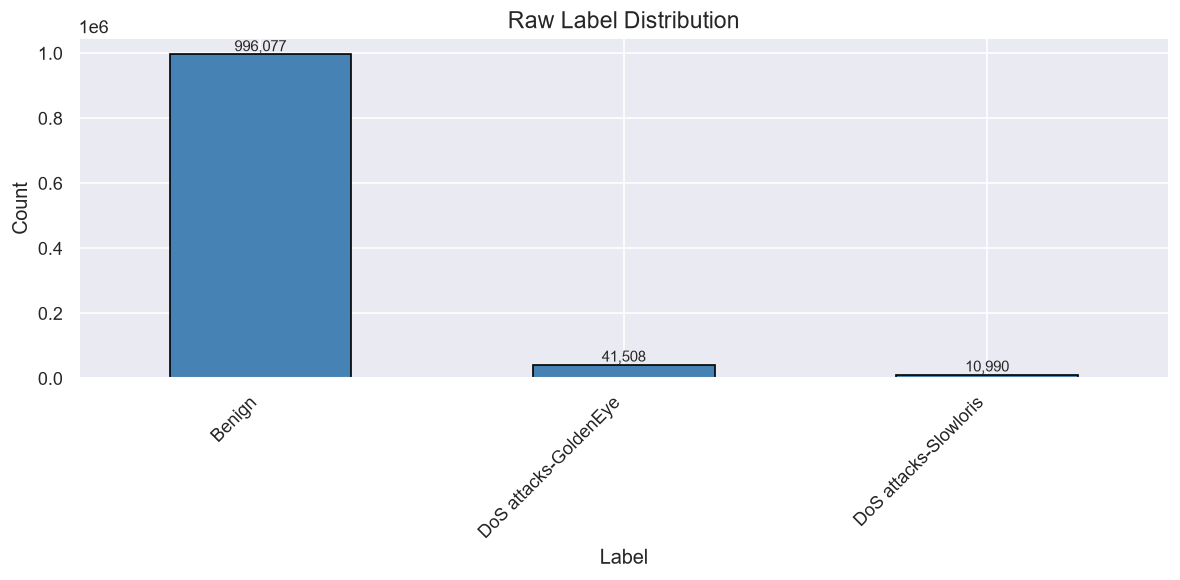

In [33]:
raw_counts = df[LABEL_COL].value_counts()
n = len(raw_counts)

fig_w = max(10, n * 0.7)
fig, ax = plt.subplots(figsize=(fig_w, 5))
raw_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Raw Label Distribution', fontsize=14)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=max(5, 9 - n // 5))
plt.tight_layout()
plt.savefig('raw_label_distribution.png', bbox_inches='tight')
plt.show()


## 4. Label Grouping
Edit `label_map` to map raw labels to your grouped class names.
Any label not in the map will be dropped (printed as a warning).

In [34]:
# ── EDIT THIS ──────────────────────────────────────────────────────────────
print(repr(df[LABEL_COL].iloc[0]))
print(df[LABEL_COL].str.strip().unique())
label_map = {
    'Benign':'Normal Attack',
    'DoS attacks-GoldenEye':'DoS',
    'DoS attacks-Slowloris':'DoS',
}
# ───────────────────────────────────────────────────────────────────────────

df[LABEL_COL] = df[LABEL_COL].str.strip()
unmapped = set(df[LABEL_COL].unique()) - set(label_map.keys())
if unmapped:
    print(f'WARNING: {len(unmapped)} unmapped labels will be dropped:')
    for u in sorted(unmapped):
        print(f'  {u!r}  ({(df[LABEL_COL] == u).sum():,} rows)')
else:
    print('All labels mapped.')

df['Attack Type'] = df[LABEL_COL].map(label_map)
dropped = df['Attack Type'].isna().sum()
df = df[df['Attack Type'].notna()].reset_index(drop=True)
print(f'\nDropped {dropped:,} rows. Remaining: {df.shape[0]:,}')

CLASS_NAMES = df['Attack Type'].value_counts().index.tolist()  # ordered by frequency
N_CLASSES = len(CLASS_NAMES)
print(f'\nClasses ({N_CLASSES}): {CLASS_NAMES}')
print()
print(df['Attack Type'].value_counts().to_string())
print(df[LABEL_COL].unique())

'Benign'
<StringArray>
['Benign', 'DoS attacks-GoldenEye', 'DoS attacks-Slowloris']
Length: 3, dtype: str
All labels mapped.

Dropped 0 rows. Remaining: 1,048,575

Classes (2): ['Normal Attack', 'DoS']

Attack Type
Normal Attack    996077
DoS               52498
<StringArray>
['Benign', 'DoS attacks-GoldenEye', 'DoS attacks-Slowloris']
Length: 3, dtype: str


## 5. Grouped Class Distribution

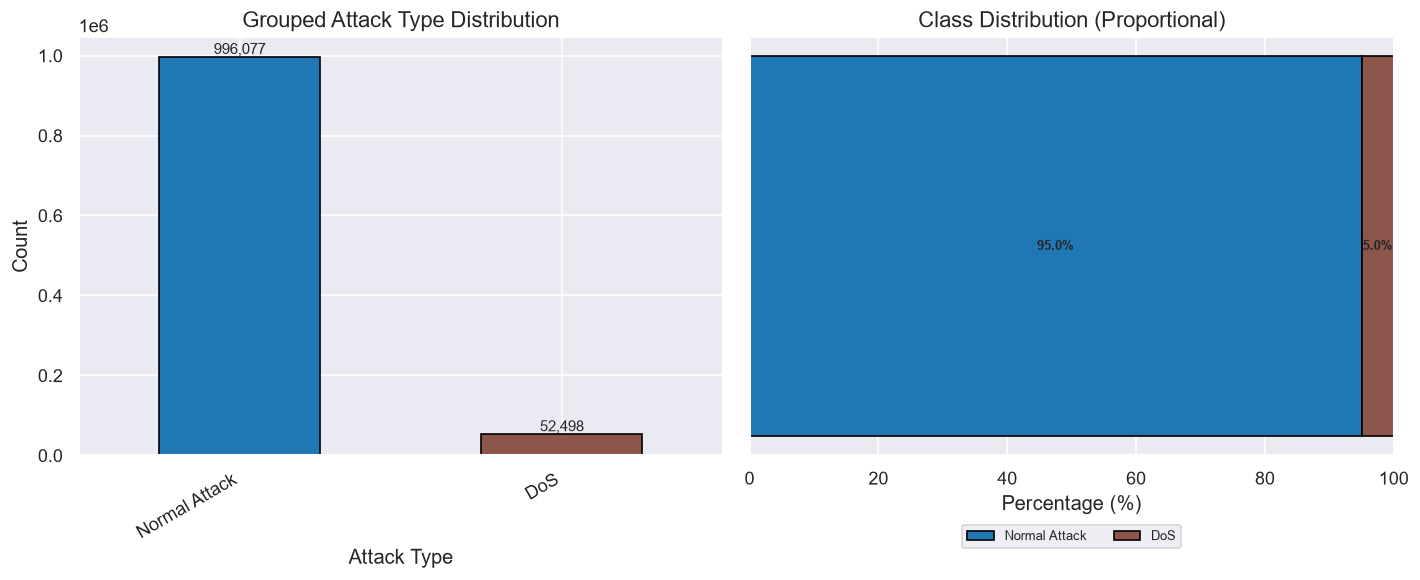

In [35]:
grouped_counts = df['Attack Type'].value_counts()
n = len(grouped_counts)

# Generate a color per class
palette = mpl.colormaps['tab10' if n <= 10 else 'tab20']
colors = [palette(i / n) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(max(12, n * 1.2), 5))

# Bar chart
grouped_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Grouped Attack Type Distribution', fontsize=13)
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=max(5, 9 - n // 4))

# Stacked horizontal bar
total = grouped_counts.sum()
percentages = (grouped_counts / total * 100).values
labels_list = grouped_counts.index.tolist()
left = 0
for i, (pct, lbl) in enumerate(zip(percentages, labels_list)):
    axes[1].barh(0, pct, left=left, color=colors[i], edgecolor='black', height=0.5, label=lbl)
    if pct > 2:
        axes[1].text(left + pct / 2, 0, f'{pct:.1f}%',
                     ha='center', va='center', fontsize=8, fontweight='bold')
    left += pct

axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Percentage (%)')
axes[1].set_yticks([])
axes[1].set_title('Class Distribution (Proportional)', fontsize=13)
ncol = max(1, min(n, 4))
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=ncol, fontsize=8)

plt.tight_layout()
plt.savefig('grouped_class_distribution.png', bbox_inches='tight')
plt.show()


## 6. Numeric Columns — Inf / Missing Values

In [36]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns: {len(numeric_cols)}')

df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

missing = df[numeric_cols].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing/inf values: {len(missing)}')
if len(missing) > 0:
    print(missing.to_string())


Numeric columns: 78
Columns with missing/inf values: 2
Flow Byts/s    8027
Flow Pkts/s    8027


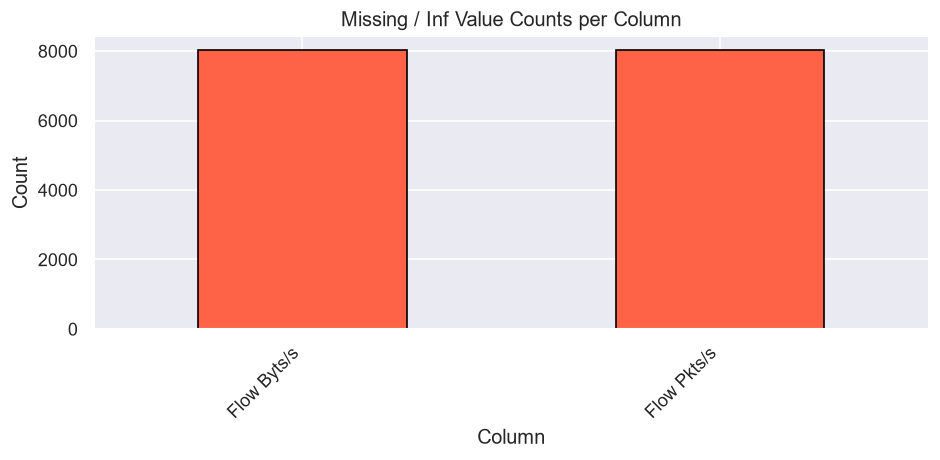

In [37]:
if len(missing) > 0:
    fig_w = max(8, len(missing) * 0.5)
    fig, ax = plt.subplots(figsize=(fig_w, 4))
    missing.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title('Missing / Inf Value Counts per Column')
    ax.set_xlabel('Column')
    ax.set_ylabel('Count')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print('No missing values after inf replacement.')


## 7. Feature Statistics

In [38]:
stats = df[numeric_cols].describe().T
stats.to_csv('feature_statistics.csv')
print(f'Saved feature_statistics.csv  ({stats.shape[0]} features)')
stats.head(20)


Saved feature_statistics.csv  (78 features)


,count,mean,std,min,25%,50%,75%,max
Dst Port,1048575.0,7.392499e+03,1.753869e+04,0.000000,53.00000,80.000000,4.450000e+02,6.553400e+04
Protocol,1048575.0,9.518465e+00,5.303721e+00,0.000000,6.00000,6.000000,1.700000e+01,1.700000e+01
Flow Duration,1048575.0,1.430739e+07,3.335503e+07,0.000000,413.00000,36896.000000,3.377079e+06,1.200000e+08
Tot Fwd Pkts,1048575.0,5.145998e+00,3.379921e+01,1.000000,1.00000,2.000000,5.000000e+00,9.021000e+03
Tot Bwd Pkts,1048575.0,6.419784e+00,9.786280e+01,0.000000,1.00000,1.000000,4.000000e+00,1.918100e+04
TotLen Fwd Pkts,1048575.0,4.354262e+02,2.881334e+04,0.000000,0.00000,44.000000,3.330000e+02,8.737314e+06
TotLen Bwd Pkts,1048575.0,4.925884e+03,1.399474e+05,0.000000,0.00000,99.000000,4.880000e+02,2.790523e+07
Fwd Pkt Len Max,1048575.0,1.514397e+02,2.774302e+02,0.000000,0.00000,41.000000,1.610000e+02,6.444000e+04
Fwd Pkt Len Min,1048575.0,1.397992e+01,2.382720e+01,0.000000,0.00000,0.000000,3.500000e+01,1.460000e+03
Fwd Pkt Len Mean,1048575.0,4.472574e+01,6.052267e+01,0.000000,0.00000,36.000000,5.366667e+01,1.652931e+04


## 8. Constant and Near-Constant Columns

In [39]:
unique_counts = df[numeric_cols].nunique()
constant_cols = unique_counts[unique_counts == 1].index.tolist()
near_constant_cols = unique_counts[unique_counts <= 2].index.tolist()
print(f'Constant columns (1 unique value):     {constant_cols}')
print(f'Near-constant columns (<=2 unique):    {near_constant_cols}')


Constant columns (1 unique value):     ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Near-constant columns (<=2 unique):    ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


## 9. Correlation Heatmap

In [40]:
sample_n = min(10_000, len(df))
sample = df[numeric_cols].dropna().sample(sample_n, random_state=42)
corr = sample.corr()

# High correlation pairs
CORR_THRESHOLD = 0.99
high_corr_pairs = [
    (corr.columns[i], corr.columns[j], corr.iloc[i, j])
    for i in range(len(corr.columns))
    for j in range(i + 1, len(corr.columns))
    if abs(corr.iloc[i, j]) >= CORR_THRESHOLD
]
print(f'Highly correlated pairs (>= {CORR_THRESHOLD}): {len(high_corr_pairs)}')
for a, b, v in high_corr_pairs:
    print(f'  {a:45s} <--> {b:45s} : {v:.4f}')


Highly correlated pairs (>= 0.99): 22
  Flow Duration                                 <--> Fwd IAT Tot                                   : 0.9947
  Tot Fwd Pkts                                  <--> Fwd Header Len                                : 0.9986
  Tot Fwd Pkts                                  <--> Subflow Fwd Pkts                              : 1.0000
  Tot Bwd Pkts                                  <--> TotLen Bwd Pkts                               : 0.9974
  Tot Bwd Pkts                                  <--> Bwd Header Len                                : 0.9998
  Tot Bwd Pkts                                  <--> Subflow Bwd Pkts                              : 1.0000
  Tot Bwd Pkts                                  <--> Subflow Bwd Byts                              : 0.9974
  TotLen Fwd Pkts                               <--> Subflow Fwd Byts                              : 1.0000
  TotLen Bwd Pkts                               <--> Bwd Header Len                               

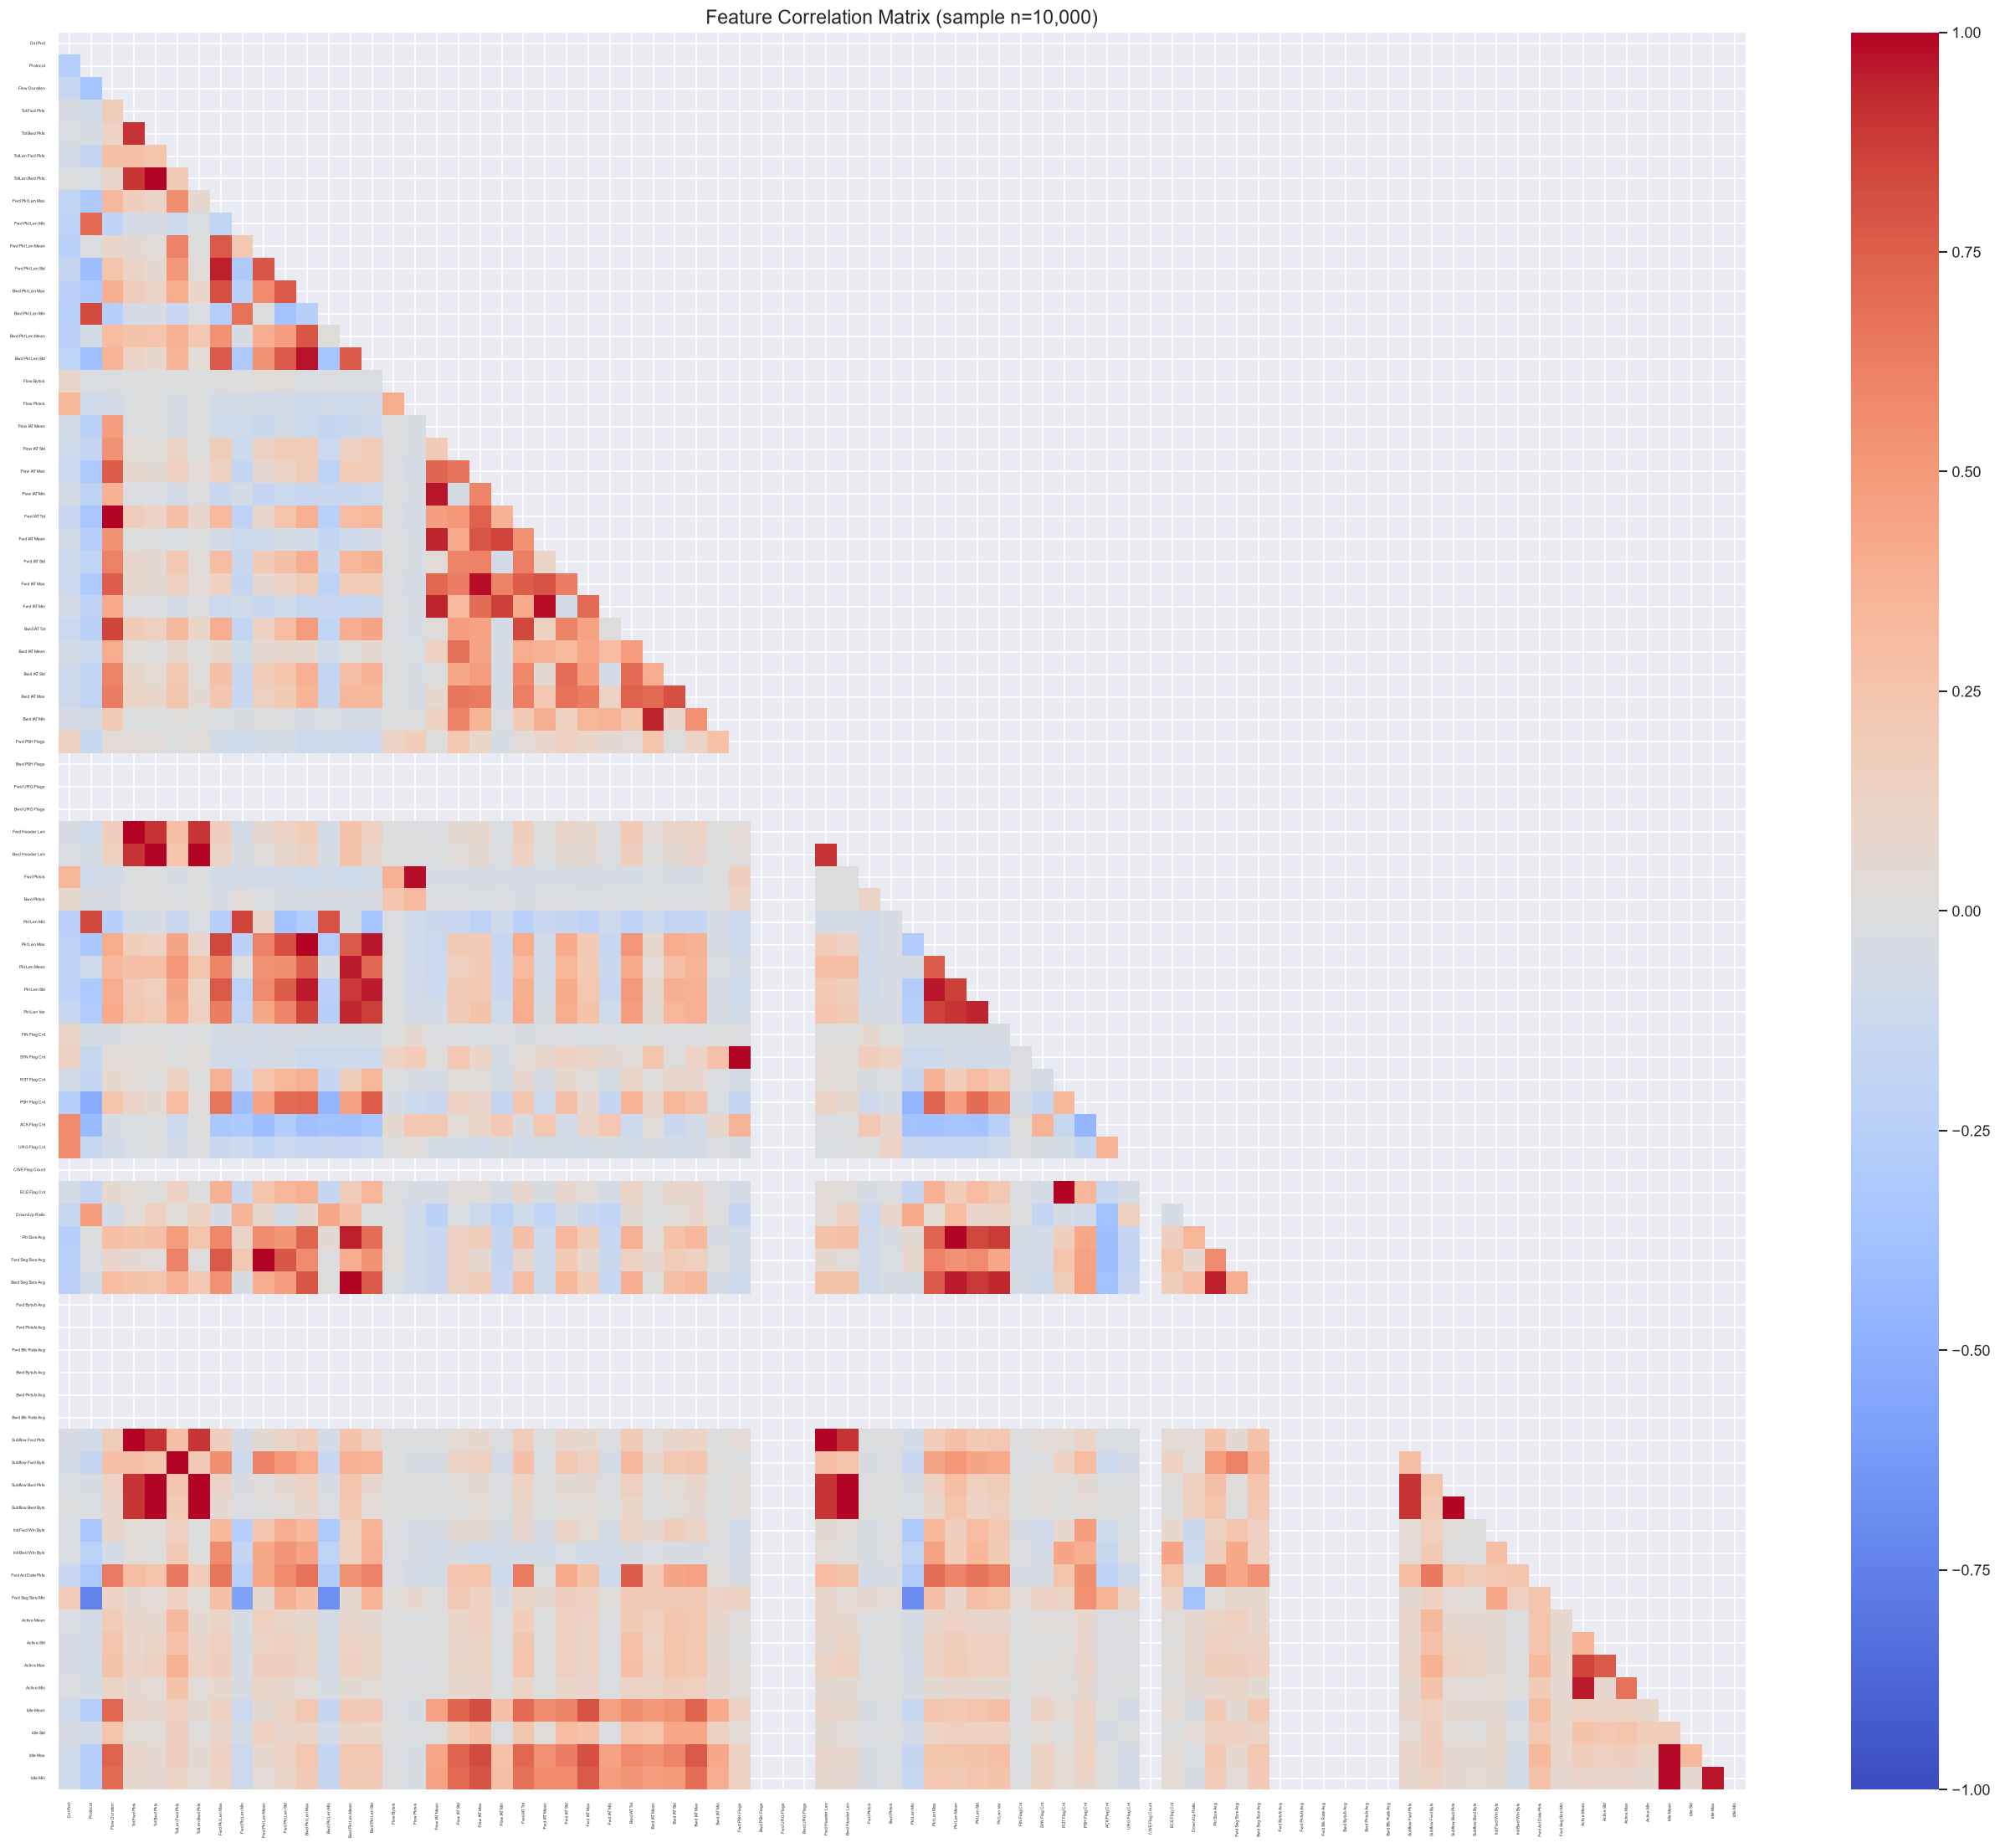

In [41]:
n_feats = len(numeric_cols)
tick_size = max(3, min(7, 120 // n_feats))
fig_size = max(14, n_feats * 0.28)

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=False,
            xticklabels=True, yticklabels=True,
            linewidths=0, ax=ax)
ax.set_title(f'Feature Correlation Matrix (sample n={sample_n:,})', fontsize=14)
ax.tick_params(axis='x', labelsize=tick_size, rotation=90)
ax.tick_params(axis='y', labelsize=tick_size)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 10. Key Feature Selection
Selects features with the highest variance (after dropping constant and highly correlated ones). Override `key_features` manually if you prefer specific ones.

In [42]:
# Drop constant cols and one from each high-corr pair
drop_for_selection = set(constant_cols)
for a, b, _ in high_corr_pairs:
    drop_for_selection.add(b)  # drop the second in each pair

candidate_cols = [c for c in numeric_cols if c not in drop_for_selection]

# Rank by variance on a sample, take top N
N_KEY = min(8, len(candidate_cols))
var_series = df[candidate_cols].var().sort_values(ascending=False)
key_features = var_series.head(N_KEY).index.tolist()

print(f'Selected {N_KEY} key features by variance:')
for f in key_features:
    print(f'  {f}')

# You can override manually:
# key_features = ['Flow Duration', 'Packet Length Mean', ...]


Selected 8 key features by variance:
  Flow Duration
  Bwd IAT Tot
  Flow IAT Max
  Fwd IAT Max
  Idle Max
  Idle Mean
  Bwd IAT Max
  Fwd IAT Mean


## 11. Feature Distributions by Attack Type

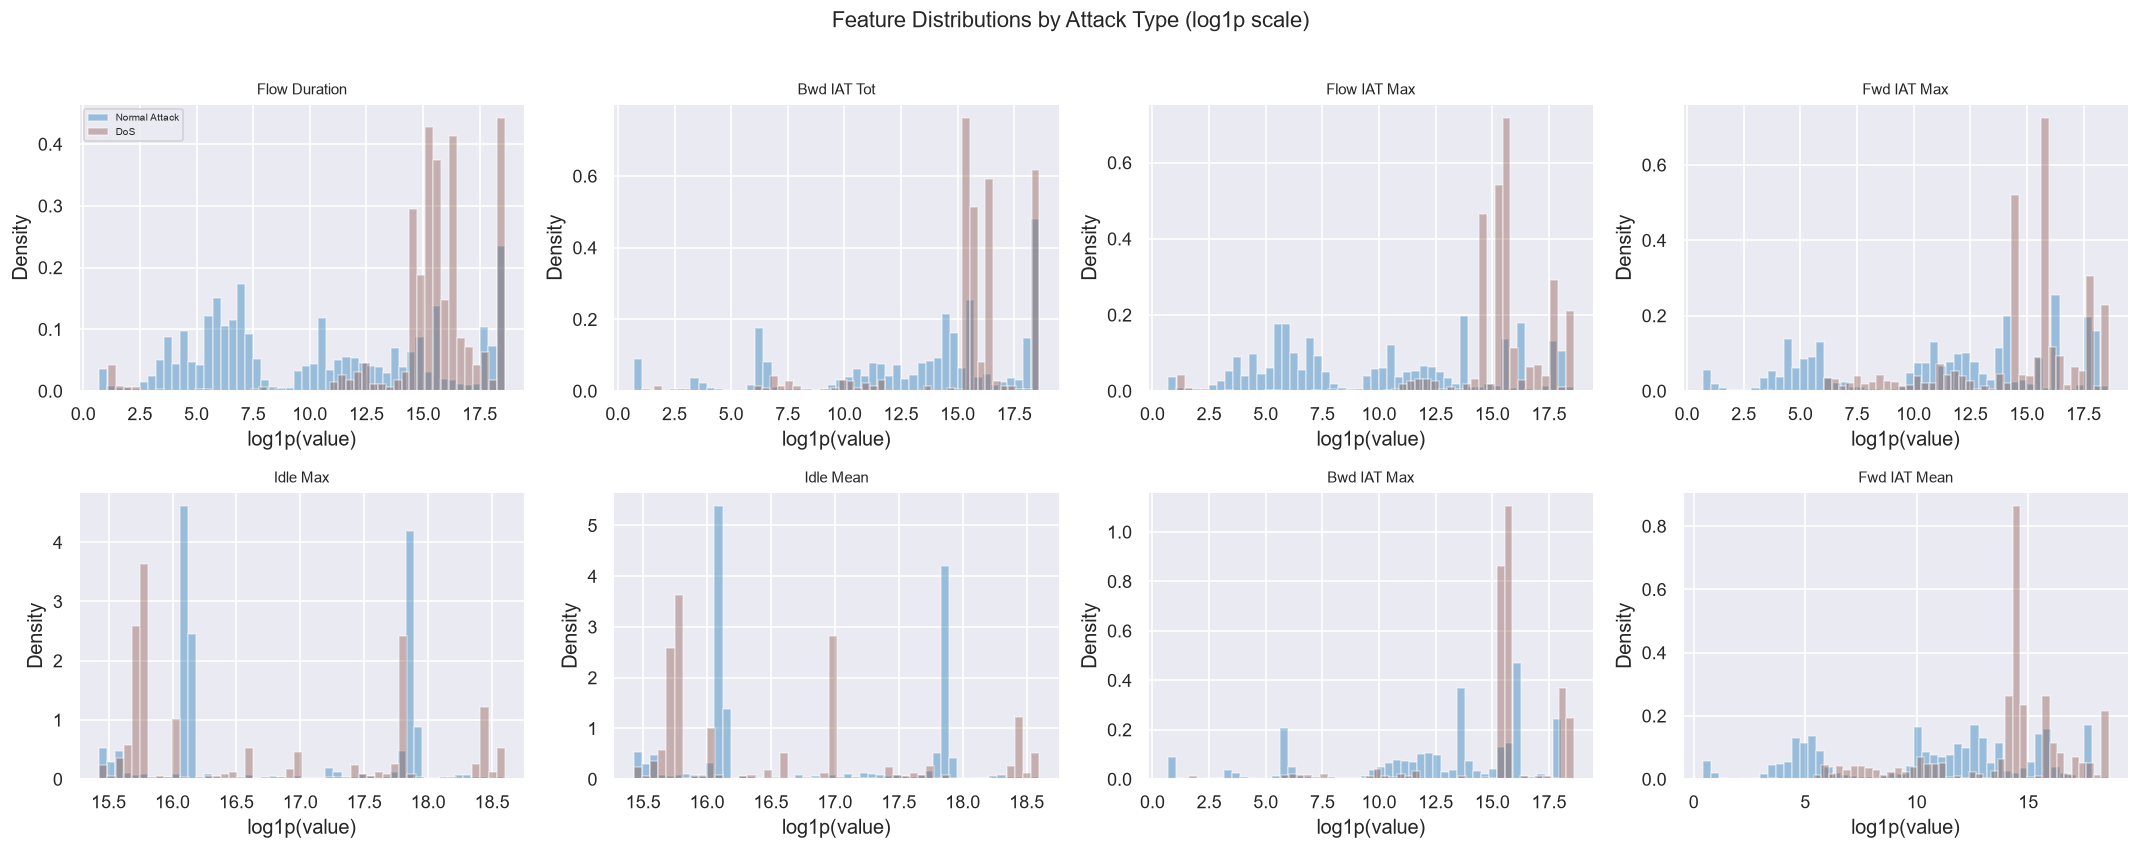

In [47]:
sample_dist = (df[key_features + ['Attack Type']]
               .dropna()
               .sample(min(20_000, len(df)), random_state=42))

n_feats = len(key_features)
ncols = min(4, n_feats)
nrows = math.ceil(n_feats / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5))
axes = np.array(axes).flatten()

# palette = mpl.colormaps['tab10' if n <= 10 else 'tab20']
# colors = [palette(i / n) for i in range(n)]
palette = mpl.colormaps['tab10' if N_CLASSES <= 10 else 'tab20']
class_colors = {cls: palette(i / N_CLASSES) for i, cls in enumerate(CLASS_NAMES)}

for i, feat in enumerate(key_features):
    for cls in CLASS_NAMES:
        subset = sample_dist[sample_dist['Attack Type'] == cls][feat]
        subset_pos = subset[subset > 0]
        if len(subset_pos) > 10:
            axes[i].hist(np.log1p(subset_pos), bins=50, alpha=0.4,
                         label=cls, density=True, color=class_colors[cls])
    axes[i].set_title(feat.strip(), fontsize=9)
    axes[i].set_xlabel('log1p(value)')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=6)

for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Attack Type (log1p scale)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions_by_class.png', bbox_inches='tight')
plt.show()


## 12. Boxplots — Key Features by Attack Type

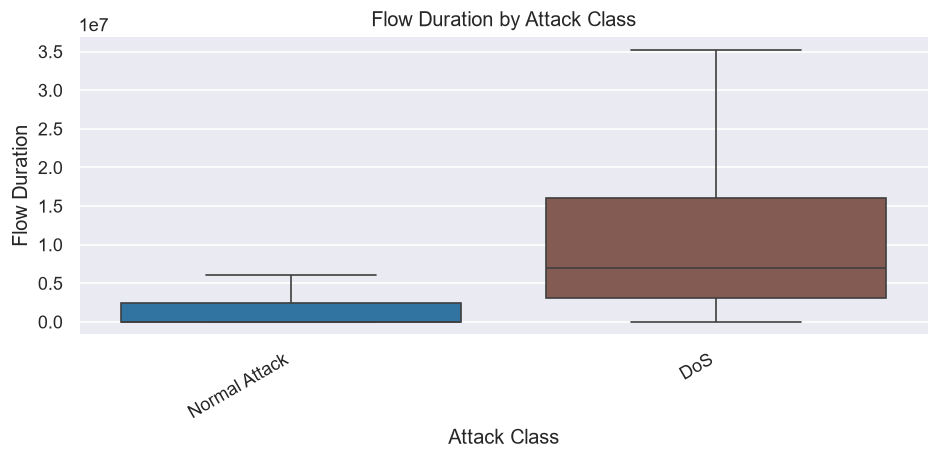

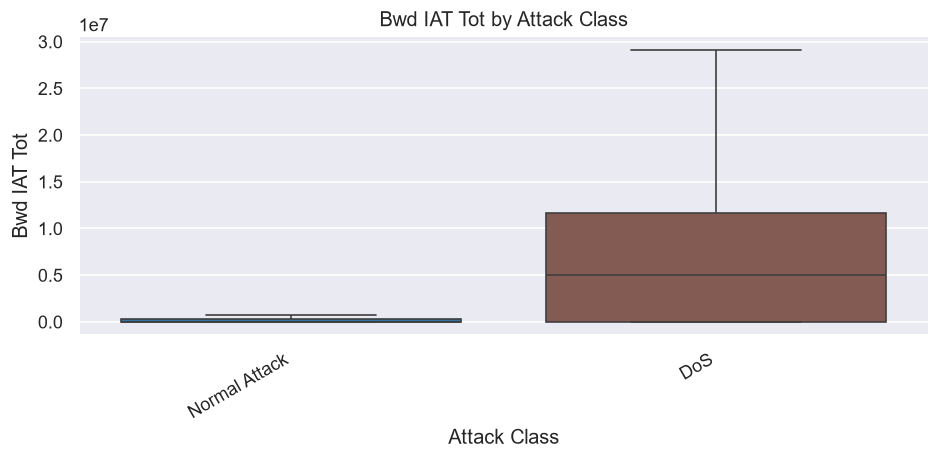

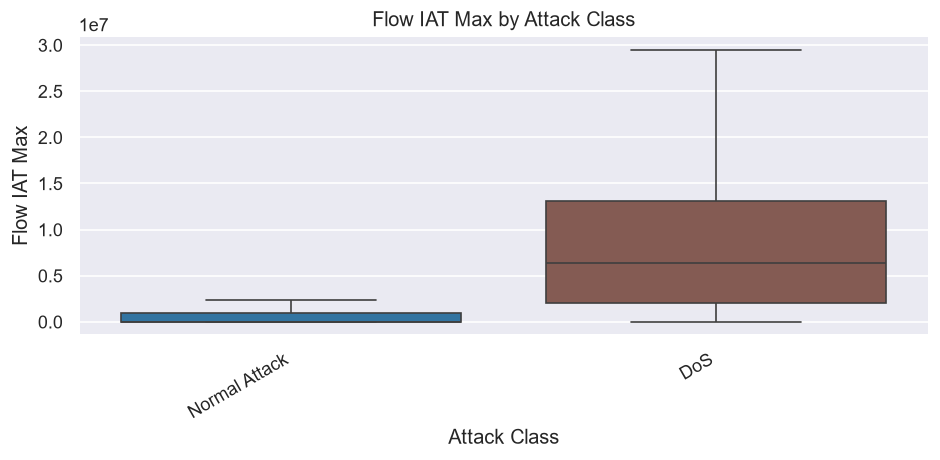

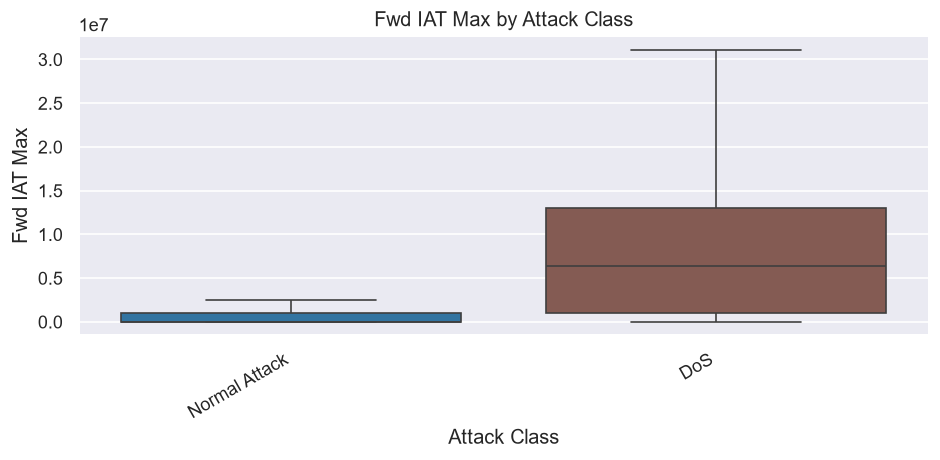

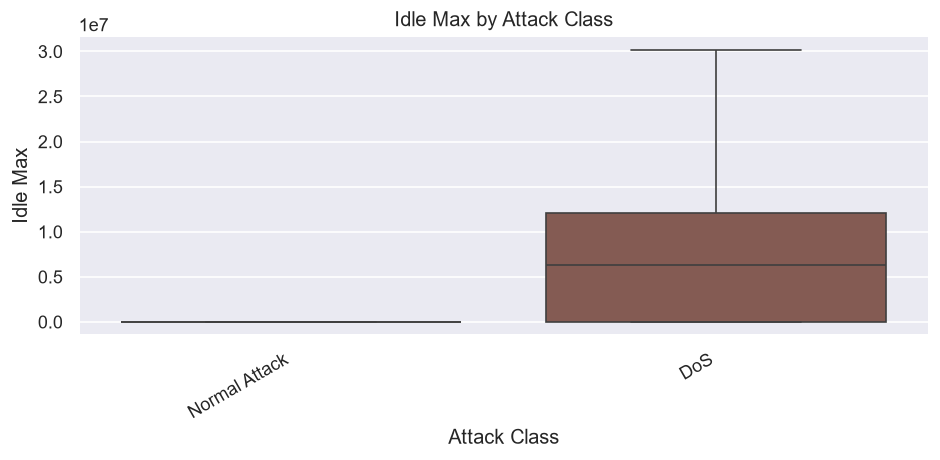

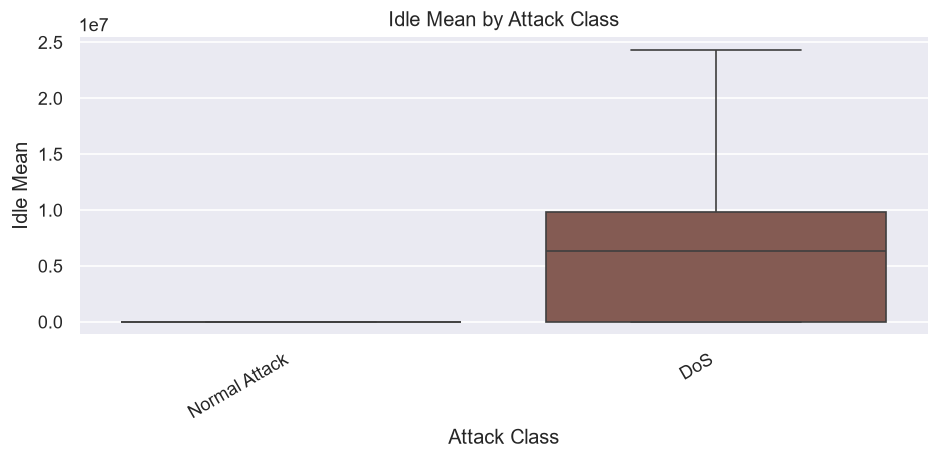

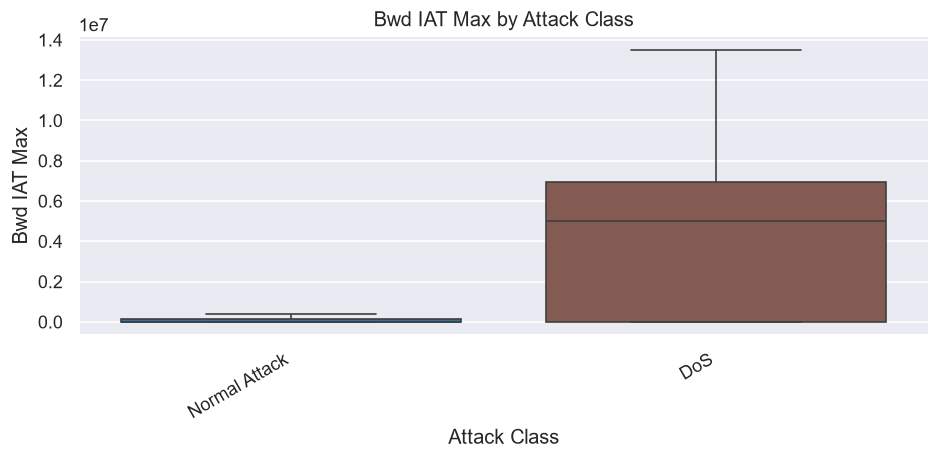

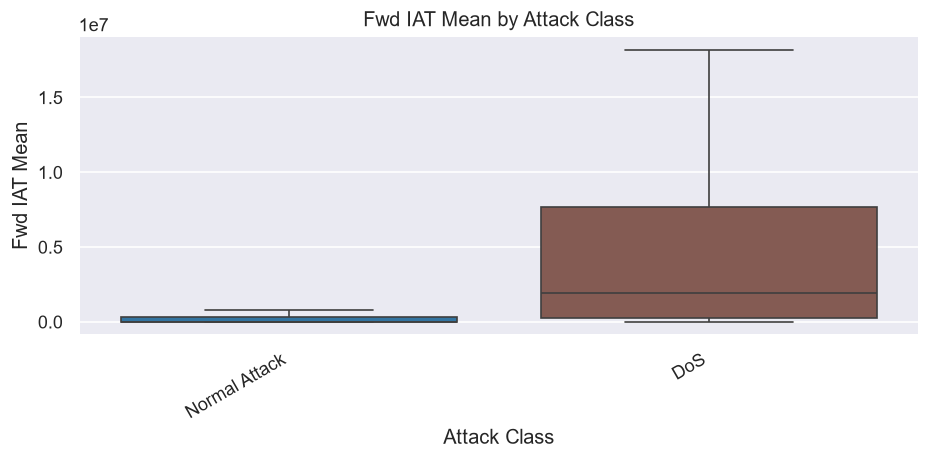

In [48]:
for i, feat in enumerate(key_features):
    fig, ax = plt.subplots(figsize=(max(8, N_CLASSES * 1.5), 4))
    sns.boxplot(data=df, x='Attack Type', y=feat,
                order=CLASS_NAMES, showfliers=False,
                palette={cls: class_colors[cls] for cls in CLASS_NAMES},
                ax=ax)
    ax.set_title(f'{feat.strip()} by Attack Class')
    ax.set_xlabel('Attack Class')
    ax.set_ylabel(feat.strip())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    safe_name = feat.strip().replace('/', '_').replace(' ', '_')
    plt.savefig(f'boxplot_{safe_name}.png', dpi=150)
    plt.show()


## 13. Per-Class Feature Means

In [49]:
per_class_means = df.groupby('Attack Type')[numeric_cols].mean().T
per_class_means.to_csv('per_class_feature_means.csv')
print('Saved: per_class_feature_means.csv')
per_class_means.head(20)


Saved: per_class_feature_means.csv


Attack Type,DoS,Normal Attack
Dst Port,8.000000e+01,7.777903e+03
Protocol,6.000000e+00,9.703904e+00
Flow Duration,2.395028e+07,1.379917e+07
Tot Fwd Pkts,4.552859e+00,5.177259e+00
Tot Bwd Pkts,2.286792e+00,6.637612e+00
TotLen Fwd Pkts,5.061431e+02,4.316991e+02
TotLen Bwd Pkts,4.509655e+02,5.161734e+03
Fwd Pkt Len Max,2.439984e+02,1.465614e+02
Fwd Pkt Len Min,9.390643e-01,1.466724e+01
Fwd Pkt Len Mean,7.328998e+01,4.322026e+01


## 14. Duplicate Row Check

In [50]:
dup_count = df.duplicated(subset=numeric_cols).sum()
print(f'Duplicate rows (on numeric features): {dup_count:,}')
print(f'As percentage: {100 * dup_count / len(df):.2f}%')


Duplicate rows (on numeric features): 163,917
As percentage: 15.63%


## 15. Preprocessing Summary

In [51]:
print('=== PREPROCESSING RECOMMENDATIONS ===')
print(f'1. Constant columns to drop ({len(constant_cols)}): {constant_cols}')
print(f'2. High-corr pairs (>= {CORR_THRESHOLD}): {len(high_corr_pairs)} — drop one from each')
print(f'3. Rows with missing/inf values: {df[numeric_cols].isna().any(axis=1).sum():,}')
print(f'4. Duplicate rows: {dup_count:,}')
print(f'5. Unmapped/dropped labels: {dropped:,} rows')
print(f'\nFinal shape: {df.shape}')
print(f'Classes: {CLASS_NAMES}')
print()
print(df['Attack Type'].value_counts().to_string())


=== PREPROCESSING RECOMMENDATIONS ===
1. Constant columns to drop (10): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
2. High-corr pairs (>= 0.99): 22 — drop one from each
3. Rows with missing/inf values: 8,027
4. Duplicate rows: 163,917
5. Unmapped/dropped labels: 0 rows

Final shape: (1048575, 82)
Classes: ['Normal Attack', 'DoS']

Attack Type
Normal Attack    996077
DoS               52498
